In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

# impute missing values of occupation column of uci dataset

In [4]:
uci['Occupation'].isnull().sum()

np.int64(1843)

In [5]:
uci['Occupation'].value_counts()

Occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [6]:
replaced_by = uci['Occupation'].mode()[0]
replaced_by

' Prof-specialty'

In [11]:
uci['Occupation'] = uci['Occupation'].fillna(replaced_by)

In [12]:
uci['Occupation'].isnull().sum()

np.int64(0)

# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

In [13]:
diabetes['age']

0        80.0
1        54.0
2        28.0
3        36.0
4        76.0
         ... 
99995    80.0
99996     2.0
99997    66.0
99998    24.0
99999    57.0
Name: age, Length: 100000, dtype: float64

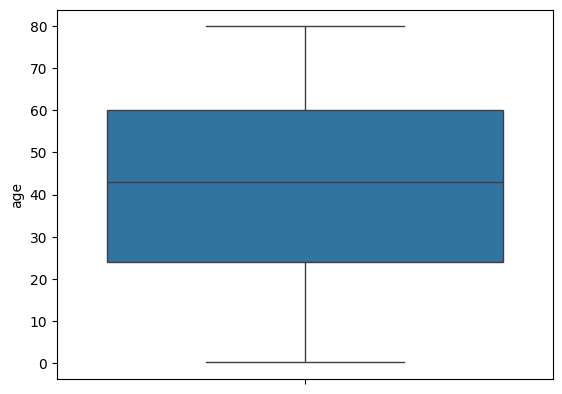

In [14]:
sns.boxplot(diabetes['age'])
plt.show()

In [15]:
diabetes['age'].describe()

count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64

In [16]:
prec25 = diabetes['age'].quantile(0.25)
prec75 = diabetes['age'].quantile(0.75)

print("25th percentile, Q1: ", prec25)
print("75th percentile, Q3: ", prec75)

25th percentile, Q1:  24.0
75th percentile, Q3:  60.0


In [17]:
IQR = prec75 - prec25
IQR

np.float64(36.0)

In [18]:
upper_limit = prec75 + 1.5 * IQR
lower_limit = prec25 - 1.5 * IQR

print("Upper limit: ", upper_limit)
print("Lower limit: ", lower_limit)

Upper limit:  114.0
Lower limit:  -30.0


In [19]:
diabetes[diabetes['age'] > upper_limit]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [20]:
diabetes[diabetes['age'] < lower_limit]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [21]:
diabetes[(diabetes['age'] > upper_limit) | (diabetes['age'] < lower_limit)]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


# Trimming

In [28]:
new_dia = diabetes[(diabetes['bmi'] < upper_limit) & (diabetes['bmi'] > lower_limit)]

In [24]:
diabetes.shape

(100000, 9)

In [26]:
new_dia_age = diabetes[(diabetes['age'] < upper_limit) & (diabetes['age'] > lower_limit)]

In [29]:
new_dia_age.shape

(100000, 9)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Capping

In [30]:
new_df_cap = diabetes.copy()

new_df_cap['age'] = np.where(new_df_cap['age'] > upper_limit, upper_limit,
                             np.where(new_df_cap['age'] < lower_limit, lower_limit, new_df_cap['age']))

In [31]:
new_df_cap.shape

(100000, 9)

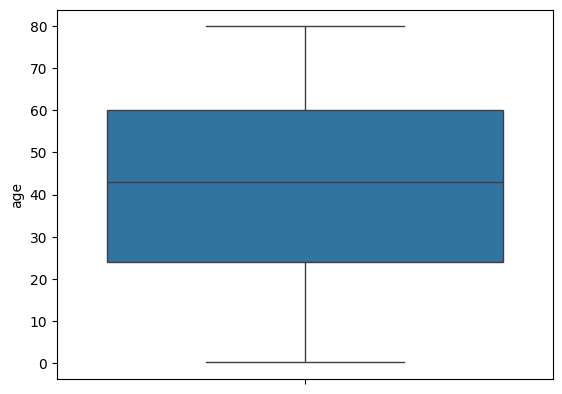

In [32]:
sns.boxplot(new_df_cap['age'])
plt.show()

# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

In [33]:
house['price']

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598    2.034000e+05
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64

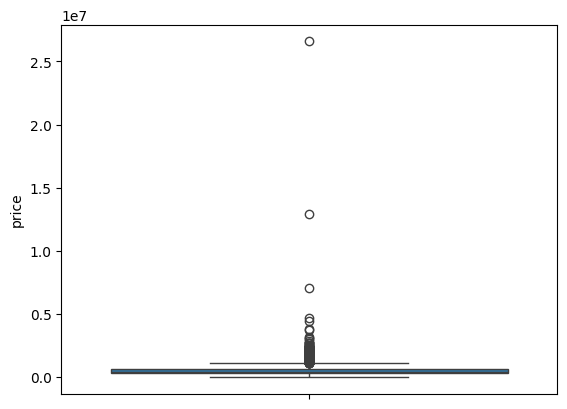

In [34]:
sns.boxplot(house['price'])
plt.show()

In [35]:
house['price'].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

In [36]:
IQR = prec75 - prec25
IQR

np.float64(36.0)

In [37]:
upper_limit = prec75 + 1.5 * IQR
lower_limit = prec25 - 1.5 * IQR

print("Upper limit: ", upper_limit)
print("Lower limit: ", lower_limit)

Upper limit:  114.0
Lower limit:  -30.0


In [38]:
house[(house['price'] > upper_limit) | (house['price'] < lower_limit)]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


# Trimming

In [39]:
house.shape

(4600, 18)

In [40]:
new_house = house[(house['price'] < upper_limit) & (house['price'] > lower_limit)]

In [41]:
new_house.shape

(49, 18)

# Capping

In [42]:
new_house_cap = house.copy()

new_house_cap['price'] = np.where(new_house_cap['price'] > upper_limit, upper_limit,
                                  np.where(new_house_cap['price'] < lower_limit, lower_limit, new_house_cap['price']))

In [43]:
new_house_cap.shape

(4600, 18)

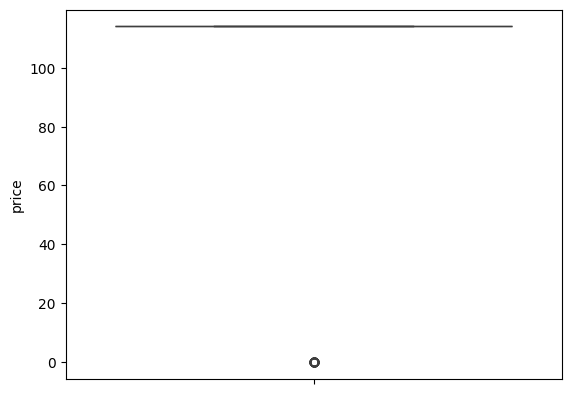

In [44]:
sns.boxplot(new_house_cap['price'])
plt.show()